# Lab19- Evaluación de algoritmos

**Materia:** Extracción de conocimiento en Bases de Datos  
**Tema:** Evaluación de algoritmos de clasificación  
**Objetivo:** Evaluar distintos algoritmos de clasificación para determinar cuál ofrece el mejor desempeño antes de integrarlo a un sistema.

In [1]:
#Importamos las librerías necesarias
import pandas as pd
import numpy as np

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

import seaborn as sns
import matplotlib.pyplot as plt

#Configuración para mostrar mejor las tablas
pd.set_option("display.max_columns", None)

In [2]:
#Cargamos el dataset Wine
#Este conjunto de datos contiene características químicas de diferentes vinos
wine = load_wine(as_frame=True)

In [3]:
#Mostramos la descripción general del dataset
print(wine.DESCR)

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:                    70.0 162.0    99.7  14.3

In [4]:
#Convertimos el dataset en un DataFrame para trabajarlo con pandas
dfWine = wine.frame

In [5]:
#Mostramos los primeros registros del dataset
dfWine.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


## Exploración del conjunto de datos

In [6]:
#Revisamos el tamaño del dataset
#Filas y columnas disponibles para el análisis
dfWine.shape

(178, 14)

In [7]:
#Mostramos los nombres de las columnas
dfWine.columns

Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline', 'target'],
      dtype='object')

In [8]:
#Mostramos las clases originales del dataset
wine.target_names

array(['class_0', 'class_1', 'class_2'], dtype='<U7')

In [9]:
#Renombramos la columna target para que sea más clara
dfWine.rename(columns={"target": "clase_vino"}, inplace=True)

In [10]:
#Cambiamos los valores numéricos por nombres de clases más comprensibles
dfWine["clase_vino"] = dfWine["clase_vino"].map({
    0: "clase_0",
    1: "clase_1",
    2: "clase_2"
})

In [11]:
#Verificamos los datos después del cambio de nombre de la variable objetivo
dfWine.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,clase_vino
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,clase_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,clase_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,clase_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,clase_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,clase_0


In [12]:
#Revisamos la cantidad de registros por cada clase de vino
dfWine["clase_vino"].value_counts()

clase_vino
clase_1    71
clase_0    59
clase_2    48
Name: count, dtype: int64

## Limpieza básica de datos

In [13]:
#Identificamos valores nulos por columna
dfWine.isnull().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
clase_vino                      0
dtype: int64

In [14]:
#Revisamos si existen registros duplicados
dfWine.duplicated().sum()

np.int64(0)

In [15]:
#Realizamos una limpieza preventiva
#Si existen duplicados, se eliminan
#Si existieran valores nulos numéricos, se rellenan con la mediana

dfWine = dfWine.drop_duplicates()

columnas_numericas = dfWine.select_dtypes(include=["int64", "float64"]).columns
for columna in columnas_numericas:
    if dfWine[columna].isnull().sum() > 0:
        dfWine[columna] = dfWine[columna].fillna(dfWine[columna].median())

print("Datos después de la limpieza:")
print("Filas y columnas:", dfWine.shape)
print("Valores nulos totales:", dfWine.isnull().sum().sum())
print("Duplicados totales:", dfWine.duplicated().sum())

Datos después de la limpieza:
Filas y columnas: (178, 14)
Valores nulos totales: 0
Duplicados totales: 0


In [16]:
#Resumen estadístico de las variables numéricas
dfWine.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


## Visualización inicial de los datos

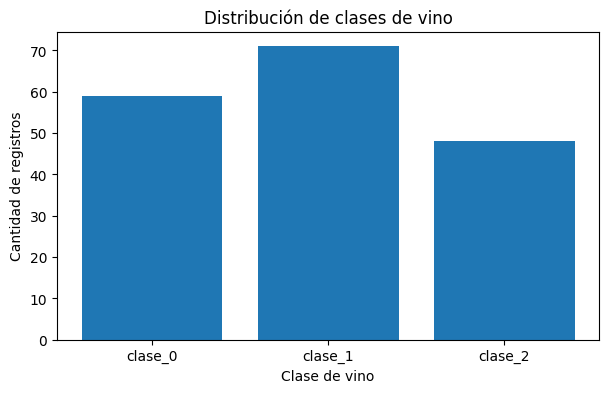

In [17]:
#Visualizamos la distribución de las clases
conteo_clases = dfWine["clase_vino"].value_counts().sort_index()

plt.figure(figsize=(7, 4))
plt.bar(conteo_clases.index, conteo_clases.values)
plt.title("Distribución de clases de vino")
plt.xlabel("Clase de vino")
plt.ylabel("Cantidad de registros")
plt.show()

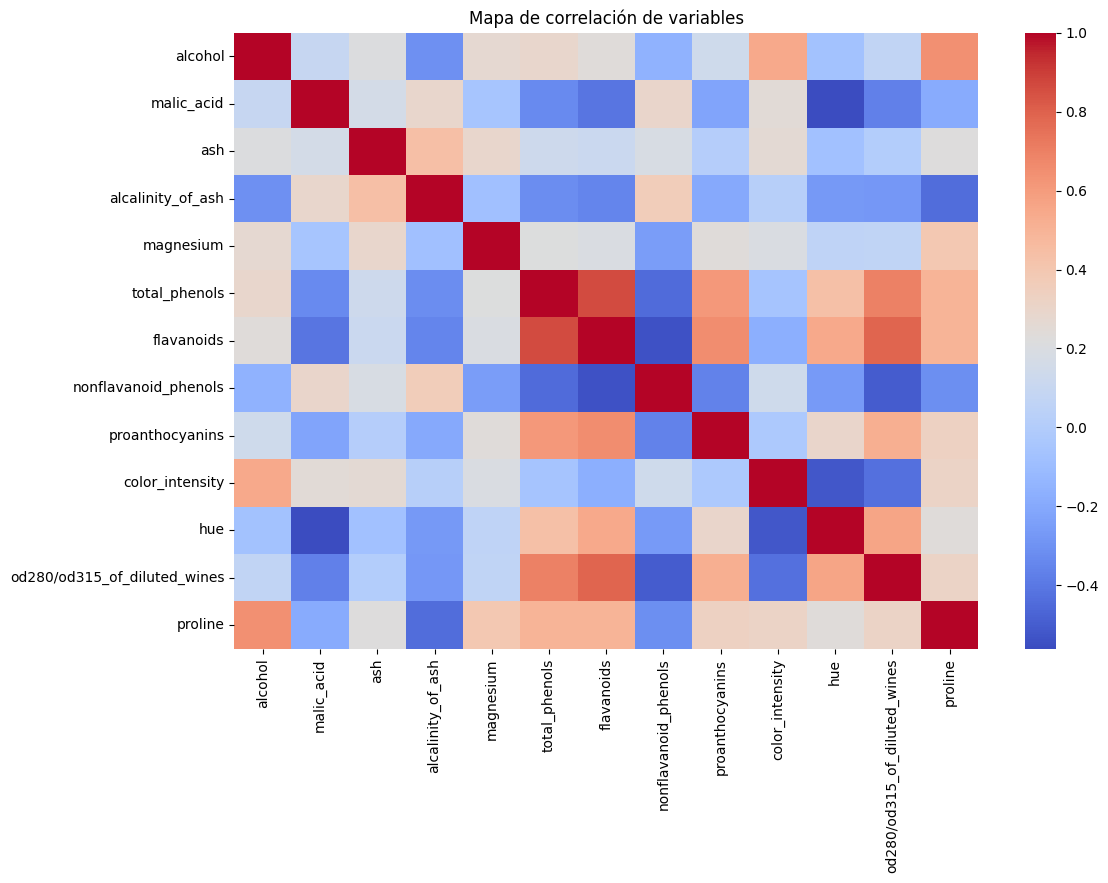

In [18]:
#Mapa de calor para observar la correlación entre variables numéricas
plt.figure(figsize=(12, 8))
sns.heatmap(dfWine[columnas_numericas].corr(), cmap="coolwarm", annot=False)
plt.title("Mapa de correlación de variables")
plt.show()

## Identificar variables predictoras y variable objetivo

In [19]:
#Variables predictoras
#Son las columnas que ayudarán al modelo a realizar la clasificación
X = dfWine.drop(columns=["clase_vino"])

In [20]:
print("Variables predictoras")
print(X.columns)

Variables predictoras
Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline'],
      dtype='object')


In [21]:
#Variable objetivo
#Es la clase que queremos predecir
y = dfWine["clase_vino"]

In [22]:
print("Variable objetivo")
print(y.name)

Variable objetivo
clase_vino


## Dividir los datos en prueba y entrenamiento

80 % para entrenamiento  
20 % para prueba

In [23]:
#Dividimos el dataset en datos de entrenamiento y prueba
#stratify ayuda a mantener la proporción de clases en ambas partes
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [24]:
print("X train", X_train.shape)
print("X test", X_test.shape)
print("y train", y_train.shape)
print("y test", y_test.shape)

X train (142, 13)
X test (36, 13)
y train (142,)
y test (36,)


## Escalado de variables

In [25]:
#Creamos el escalador
#El escalado ayuda especialmente a modelos como KNN, SVM y Regresión Logística
scaler = StandardScaler()

In [26]:
#Ajustamos el escalador solo con los datos de entrenamiento
X_train_escalado = scaler.fit_transform(X_train)

In [27]:
#Transformamos los datos de prueba usando el mismo escalador
X_test_escalado = scaler.transform(X_test)

In [28]:
print("Sin escalar")
print(X_train.head())
print("Escalado")
print(X_train_escalado[:5])

Sin escalar
     alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
36     13.28        1.64  2.84               15.5      110.0           2.60   
30     13.73        1.50  2.70               22.5      101.0           3.00   
26     13.39        1.77  2.62               16.1       93.0           2.85   
12     13.75        1.73  2.41               16.0       89.0           2.60   
148    13.32        3.24  2.38               21.5       92.0           1.93   

     flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
36         2.68                  0.34             1.36             4.60  1.09   
30         3.25                  0.29             2.38             5.70  1.19   
26         2.94                  0.34             1.45             4.80  0.92   
12         2.76                  0.29             1.81             5.60  1.15   
148        0.76                  0.45             1.25             8.42  0.55   

     od280/od315_of_dilute

## Evaluación de distintos algoritmos

En esta práctica se comparan varios algoritmos de clasificación para elegir el que tenga mejor desempeño.

In [29]:
#Definimos los modelos que vamos a evaluar
#Se usan los mismos datos de entrenamiento y prueba para que la comparación sea justa
modelos = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Árbol de Decisión": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Regresión Logística": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(kernel="rbf", random_state=42)
}

In [30]:
#Entrenamos y evaluamos cada algoritmo
#Guardamos las métricas principales para poder compararlas

resultados = []
modelos_entrenados = {}
predicciones = {}

for nombre, modelo in modelos.items():
    #Entrenamiento del modelo
    modelo.fit(X_train_escalado, y_train)

    #Predicción con datos de prueba
    y_pred = modelo.predict(X_test_escalado)

    #Guardamos el modelo y sus predicciones
    modelos_entrenados[nombre] = modelo
    predicciones[nombre] = y_pred

    #Calculamos métricas de evaluación
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    recall = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    resultados.append({
        "Algoritmo": nombre,
        "Accuracy": accuracy,
        "Precisión": precision,
        "Recall": recall,
        "F1-score": f1
    })

#Convertimos los resultados a DataFrame
dfResultados = pd.DataFrame(resultados)
dfResultados

,Algoritmo,Accuracy,Precisión,Recall,F1-score
0,KNN,0.972222,0.974747,0.972222,0.972369
1,Árbol de Decisión,0.944444,0.951389,0.944444,0.944961
2,Random Forest,1.000000,1.000000,1.000000,1.000000
3,Regresión Logística,0.972222,0.974074,0.972222,0.971970
4,SVM,0.972222,0.974074,0.972222,0.971970


In [31]:
#Ordenamos los algoritmos de mayor a menor desempeño usando F1-score
dfResultadosOrdenados = dfResultados.sort_values(by="F1-score", ascending=False)
dfResultadosOrdenados

,Algoritmo,Accuracy,Precisión,Recall,F1-score
2,Random Forest,1.000000,1.000000,1.000000,1.000000
0,KNN,0.972222,0.974747,0.972222,0.972369
3,Regresión Logística,0.972222,0.974074,0.972222,0.971970
4,SVM,0.972222,0.974074,0.972222,0.971970
1,Árbol de Decisión,0.944444,0.951389,0.944444,0.944961


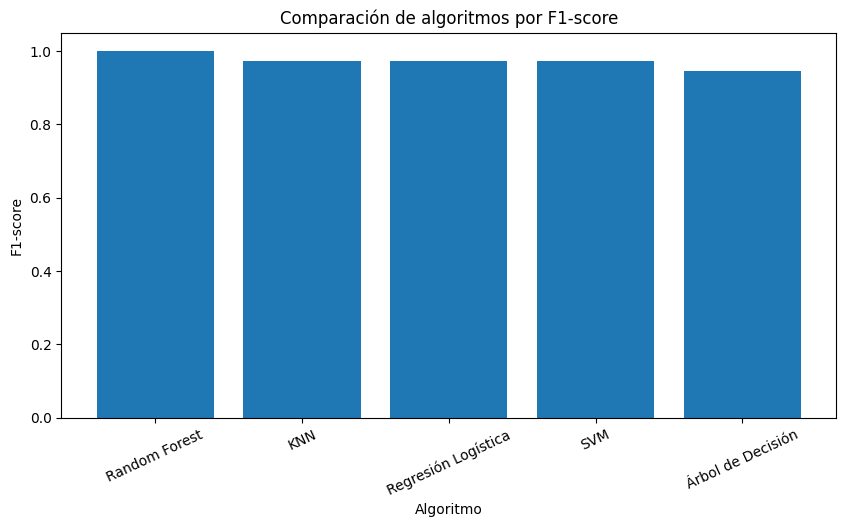

In [32]:
#Graficamos la comparación de los algoritmos
plt.figure(figsize=(10, 5))
plt.bar(dfResultadosOrdenados["Algoritmo"], dfResultadosOrdenados["F1-score"])
plt.title("Comparación de algoritmos por F1-score")
plt.xlabel("Algoritmo")
plt.ylabel("F1-score")
plt.xticks(rotation=25)
plt.ylim(0, 1.05)
plt.show()

In [33]:
#Seleccionamos el mejor algoritmo tomando como referencia el F1-score
mejor_algoritmo = dfResultadosOrdenados.iloc[0]["Algoritmo"]
mejor_f1 = dfResultadosOrdenados.iloc[0]["F1-score"]

print("Mejor algoritmo:", mejor_algoritmo)
print("F1-score:", mejor_f1)

Mejor algoritmo: Random Forest
F1-score: 1.0


## Matriz de confusión del mejor algoritmo

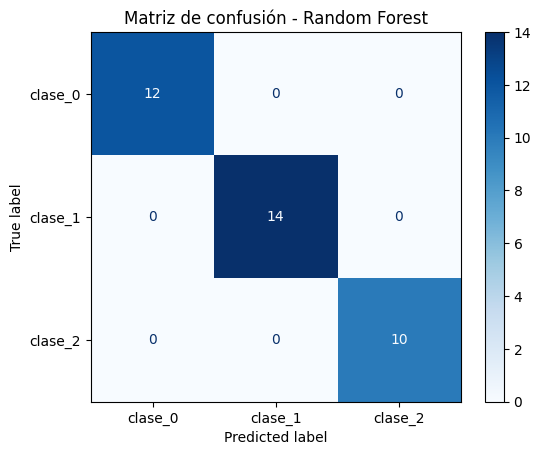

In [34]:
#Obtenemos las predicciones del mejor algoritmo
y_pred_mejor = predicciones[mejor_algoritmo]

#Generamos la matriz de confusión
matriz = confusion_matrix(y_test, y_pred_mejor)

#Mostramos la matriz de confusión de forma visual
display = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=modelos_entrenados[mejor_algoritmo].classes_
)
display.plot(cmap="Blues", values_format="d")
plt.title("Matriz de confusión - " + mejor_algoritmo)
plt.show()

In [35]:
#Reporte de clasificación del mejor algoritmo
print("Reporte de clasificación del mejor algoritmo:")
print(classification_report(y_test, y_pred_mejor))

Reporte de clasificación del mejor algoritmo:
              precision    recall  f1-score   support

     clase_0       1.00      1.00      1.00        12
     clase_1       1.00      1.00      1.00        14
     clase_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



## Prueba con nuevos registros

In [36]:
#Tomamos algunos registros del conjunto de prueba para revisar predicciones reales
muestra = X_test.head(5)
muestra_escalada = scaler.transform(muestra)

prediccion_muestra = modelos_entrenados[mejor_algoritmo].predict(muestra_escalada)

comparacion = muestra.copy()
comparacion["Clase real"] = y_test.head(5).values
comparacion["Predicción"] = prediccion_muestra
comparacion

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Clase real,Predicción
10,14.10,2.16,2.30,18.0,105.0,2.95,3.32,0.22,2.38,5.75,1.25,3.17,1510.0,clase_0,clase_0
134,12.51,1.24,2.25,17.5,85.0,2.00,0.58,0.60,1.25,5.45,0.75,1.51,650.0,clase_2,clase_2
28,13.87,1.90,2.80,19.4,107.0,2.95,2.97,0.37,1.76,4.50,1.25,3.40,915.0,clase_0,clase_0
121,11.56,2.05,3.23,28.5,119.0,3.18,5.08,0.47,1.87,6.00,0.93,3.69,465.0,clase_1,clase_1
62,13.67,1.25,1.92,18.0,94.0,2.10,1.79,0.32,0.73,3.80,1.23,2.46,630.0,clase_1,clase_1


## Conclusiones

En este laboratorio se evaluaron diferentes algoritmos de clasificación utilizando el dataset Wine. Antes de entrenar los modelos, se realizó una exploración del conjunto de datos para conocer sus columnas, clases, valores nulos y registros duplicados.

Durante la limpieza se verificó que el dataset no presentara problemas importantes; aun así, se aplicó una limpieza preventiva eliminando duplicados y preparando una estrategia para rellenar valores nulos numéricos con la mediana si fuera necesario. Esta decisión ayuda a evitar errores durante el entrenamiento.

También se aplicó escalado de variables porque algunos algoritmos, como KNN, SVM y Regresión Logística, pueden verse afectados cuando las variables tienen escalas diferentes. Al comparar los resultados mediante Accuracy, Precisión, Recall y F1-score, se pudo identificar cuál algoritmo tuvo el mejor desempeño en los datos de prueba.

La evaluación de algoritmos es importante porque no siempre el primer modelo elegido es el más adecuado. Comparar varios modelos permite tomar una mejor decisión antes de integrar un algoritmo a un sistema real.